In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文字體，解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 設定字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# 設定風格
sns.set_theme(style="whitegrid")
np.random.seed(42) # 固定亂數種子，讓你跑出來的結果跟我一樣

n_companies = 100
years = 3
total_rows = n_companies * years

# 1. 模擬 ESG 分數 (0-100分)
# 假設 E, S, G 三個面向的分數
e_scores = np.random.normal(60, 15, total_rows)
s_scores = np.random.normal(65, 10, total_rows)
g_scores = np.random.normal(70, 12, total_rows)

# 限制分數在 0-100 之間
e_scores = np.clip(e_scores, 0, 100)
s_scores = np.clip(s_scores, 0, 100)
g_scores = np.clip(g_scores, 0, 100)

# 計算總分 (假設權重一樣)
total_esg = (e_scores + s_scores + g_scores) / 3

# 2. 模擬股東投資績效 (年化報酬率 %)
# 這裡我們設定一個 "隱藏規則"：G (公司治理) 分數高的，報酬率通常會好一點點 (係數 0.3)
# E 和 S 則影響較小，再加上很多隨機波動 (Noise)
random_noise = np.random.normal(0, 20, total_rows) # 市場波動很大
returns = -10 + (0.1 * e_scores) + (0.05 * s_scores) + (0.3 * g_scores) + random_noise

# 3. 建立 DataFrame
df = pd.DataFrame({
    'Company_ID': [f'Comp_{i}' for i in range(1, n_companies+1)] * years,
    'E_Score': e_scores,
    'S_Score': s_scores,
    'G_Score': g_scores,
    'Total_ESG': total_esg,
    'Annual_Return': returns
})

print("--- 資料庫樣本 (前 5 筆) ---")
print(df.head())

--- 資料庫樣本 (前 5 筆) ---
  Company_ID    E_Score    S_Score    G_Score  Total_ESG  Annual_Return
0     Comp_1  67.450712  56.710050  79.083863  67.748209      30.679199
1     Comp_2  57.926035  59.398190  58.934016  58.752747       8.575942
2     Comp_3  69.715328  72.472936  80.435271  74.207845      25.300657
3     Comp_4  82.845448  71.103703  86.267654  80.072268      53.289063
4     Comp_5  56.487699  64.790984  74.961219  65.413301      25.198666



--- 相關係數表 ---
E_Score          0.124323
S_Score         -0.032427
G_Score          0.161836
Total_ESG        0.167916
Annual_Return    1.000000
Name: Annual_Return, dtype: float64


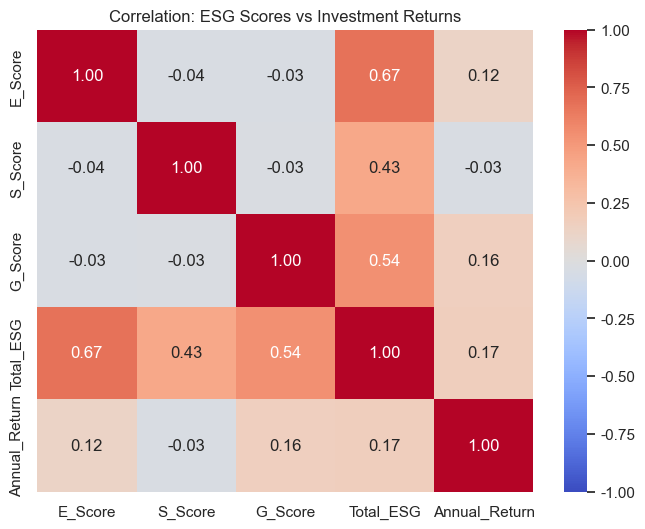

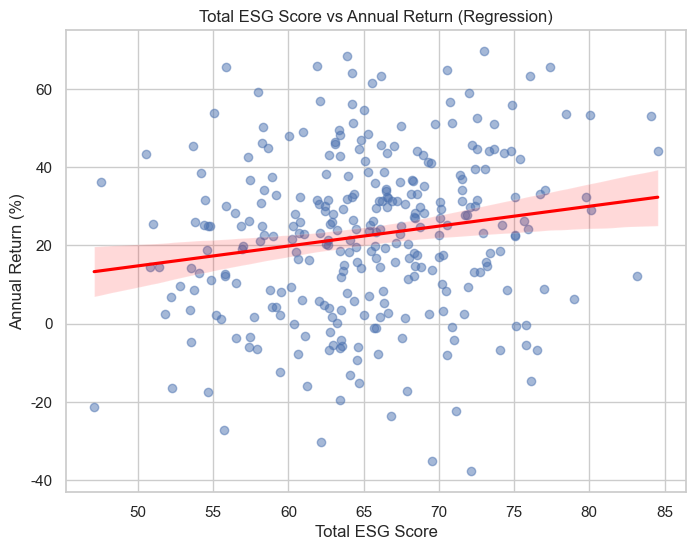

In [5]:
# 1. 計算相關係數矩陣
correlation_matrix = df[['E_Score', 'S_Score', 'G_Score', 'Total_ESG', 'Annual_Return']].corr()

print("\n--- 相關係數表 ---")
print(correlation_matrix['Annual_Return']) # 我們只關心跟 "報酬率" 的關係

# 2. 畫出熱力圖 (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation: ESG Scores vs Investment Returns')
# plt.savefig('esg_correlation.png')
plt.show()

# 3. 畫出散佈圖 (Scatter Plot) - 看看趨勢線
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Total_ESG', y='Annual_Return', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Total ESG Score vs Annual Return (Regression)')
plt.xlabel('Total ESG Score')
plt.ylabel('Annual Return (%)')
# plt.savefig('esg_regression.png')
plt.show()

In [ ]:
# 1. 將公司分為 "High ESG" (前 50%) 和 "Low ESG" (後 50%)
median_score = df['Total_ESG'].median()

# 使用 np.where 貼標籤
df['ESG_Group'] = np.where(df['Total_ESG'] >= median_score, 'High ESG (Good)', 'Low ESG (Bad)')

# 2. 計算兩組的平均報酬率
group_performance = df.groupby('ESG_Group')['Annual_Return'].agg(['mean', 'std', 'count'])

print("\n--- ESG 優等生 vs 後段班 績效大比拚 ---")
print(group_performance)

# 3. 視覺化比較 (Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='ESG_Group', y='Annual_Return', palette={'High ESG (Good)': 'green', 'Low ESG (Bad)': 'gray'})
plt.title('Performance Comparison: High vs Low ESG')
plt.ylabel('Annual Return (%)')
# plt.savefig('esg_group_comparison.png')
plt.show()